In [ ]:
# This file is used to compare the results of mitosis, amitosis and sex (different frequency) with the Multiplicative version model. For each simulation,
# the evolution was run for 100K generations, and the population size is 5, 10, 20 and 50. The raw data used by this file can be 
# found in the following folder:
# Amitosis: 
# F:\Prof. Azevedo\Simulation of Ciliate Evolution\1215_Monitor Mutation Dynamics_Pop and Ind level_Add Multiplicative Version to Calculate Fitness and Check Equilibrium\Data\Evolve for 100K
# Mitosis: 
# F:\Prof. Azevedo\Simulation of Ciliate Evolution\1219_Monitor Mutation Dynamics_Pop and Ind level_MUL Version_Mitosis with N =5, 10, 20 and 50 for 100K G\Data
# Sex reproduction with Every Generation:
# "F:\Prof. Azevedo\Simulation of Ciliate Evolution\1220_Monitor Mutation Dynamics_Pop and Ind level_MUL Version_Sex Every Generation with N =5, 10, 20, 50 and 100 for 100K G\Data"
# Sex reproduction with Every 10, 60 and 100 Generation:
# "F:\Prof. Azevedo\Simulation of Ciliate Evolution\1228_Monitor Mutation Dynamics_MUL_Have Sex Every 10, 60 and 100 Generation with N =5, 10, 20, 50 and 100 for 100K G\Data"

# In this file, the mean fitness, the log mean fitness and the log of mean fitness were compared, and the figures plotted by this
# file can be found in the following folder:  (Figures of Mitosis and Amitosis)
# "F:\Prof. Azevedo\Simulation of Ciliate Evolution\1219_Monitor Mutation Dynamics_Pop and Ind level_MUL Version_Mitosis with N =5, 10, 20 and 50 for 100K G\Figures"

# The figures plotted by this file can be found in the following folder:
# "F:\Prof. Azevedo\Simulation of Ciliate Evolution\1228_Monitor Mutation Dynamics_MUL_Have Sex Every 10, 60 and 100 Generation with N =5, 10, 20, 50 and 100 for 100K G\Figures\Comparison of Mito, Amito and Diff Freq of Sex_Fitness"

# The revised figures can be found in the following folder:
# "F:\Prof. Azevedo\Simulation of Ciliate Evolution\1228_Monitor Mutation Dynamics_MUL_Have Sex Every 10, 60 and 100 Generation with N =5, 10, 20, 50 and 100 for 100K G\Figures\log Mean Fit_Revised Fig"

In [1]:
import numpy as np
import scipy.spatial as spa
import random
import pandas as pd 
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy.linalg import hadamard
import itertools as it 
import scipy.stats as stat
import scipy.integrate as integrate
import math
import argparse
import os

In [2]:
generation_list = []

for i in range(10002):
    generation_list.append(i)
    
print(len(generation_list))

10002


In [7]:
# Amitosis
os.chdir(r"F:\Prof. Azevedo\Simulation of Ciliate Evolution\20170107_Comparison of Fitness Change of Amito, Mito and Sex (Diff Freq) for 10K_Som and Germ_Stride =1\Data\Result_Amito")

In [8]:
amito_file = ['G_Fitness_WF_Amito_5_E1_10K.csv', 'G_Fitness_WF_Amito_10_E1_10K.csv', 'G_Fitness_WF_Amito_20_E1_10K.csv', \
             'G_Fitness_WF_Amito_50_E1_10K.csv']


amito_mfit = []
amito_log_mfit = []
amito_mlog_fit = []

g_amito_mfit = []
g_amito_log_mfit = []
g_amito_mlog_fit = []


for i in amito_file:
    amito = pd.read_csv(i,dtype=str)
    
    mfit = []
    log_mfit = []
    mlog_fit = []
    
    g_mfit = []
    g_log_mfit = []
    g_mlog_fit = []    
    
    mfit.extend(list(pd.Series(amito.meanFit,dtype=float)))
    log_mfit.extend(list(pd.Series(amito.log_meanFit,dtype=float)))
    mlog_fit.extend(list(pd.Series(amito.mean_logFit, dtype=float)))
    
    g_mfit.extend(list(pd.Series(amito.meanFit_Germ,dtype=float)))
    g_log_mfit.extend(list(pd.Series(amito.log_meanFit_Germ,dtype=float)))
    g_mlog_fit.extend(list(pd.Series(amito.mean_logFit_Germ, dtype=float)))    
                
    amito_mfit.append(mfit)
    amito_log_mfit.append(log_mfit)
    amito_mlog_fit.append(mlog_fit)

    
    g_amito_mfit.append(g_mfit)
    g_amito_log_mfit.append(g_log_mfit)
    g_amito_mlog_fit.append(g_mlog_fit)

In [9]:
len(amito_mfit[0])

10002

In [10]:
# Mitosis
os.chdir(r"F:\Prof. Azevedo\Simulation of Ciliate Evolution\20170107_Comparison of Fitness Change of Amito, Mito and Sex (Diff Freq) for 10K_Som and Germ_Stride =1\Data\Result_Mito")

In [11]:
mito_file = ['G_Fitness_WF_Mito_5_E1_10K.csv', 'G_Fitness_WF_Mito_10_E1_10K.csv', 'G_Fitness_WF_Mito_20_E1_10K.csv', \
             'G_Fitness_WF_Mito_50_E1_10K.csv']


mito_mfit = []
mito_log_mfit = []
mito_mlog_fit = []

g_mito_mfit = []
g_mito_log_mfit = []
g_mito_mlog_fit = []

for i in mito_file:
    mito = pd.read_csv(i,dtype=str)
    
    mfit = []
    log_mfit = []
    mlog_fit = []
    
    g_mfit = []
    g_log_mfit = []
    g_mlog_fit = []    
    
    mfit.extend(list(pd.Series(mito.meanFit,dtype=float)))
    log_mfit.extend(list(pd.Series(mito.log_meanFit,dtype=float)))
    mlog_fit.extend(list(pd.Series(mito.mean_logFit, dtype=float)))
    
    g_mfit.extend(list(pd.Series(mito.meanFit_Germ,dtype=float)))
    g_log_mfit.extend(list(pd.Series(mito.log_meanFit_Germ,dtype=float)))
    g_mlog_fit.extend(list(pd.Series(mito.mean_logFit_Germ, dtype=float)))    
                
    mito_mfit.append(mfit)
    mito_log_mfit.append(log_mfit)
    mito_mlog_fit.append(mlog_fit)
    
    g_mito_mfit.append(g_mfit)
    g_mito_log_mfit.append(g_log_mfit)
    g_mito_mlog_fit.append(g_mlog_fit)

In [12]:
# Sexual reproduction every generation
os.chdir(r"F:\Prof. Azevedo\Simulation of Ciliate Evolution\20170107_Comparison of Fitness Change of Amito, Mito and Sex (Diff Freq) for 10K_Som and Germ_Stride =1\Data\Result_Sex Every 1G")

In [13]:
sf1_file = ['G_Fitness_WF_SF_5_E1_10K.csv', 'G_Fitness_WF_SF_10_E1_10K.csv', 'G_Fitness_WF_SF_20_E1_10K.csv', \
             'G_Fitness_WF_SF_50_E1_10K.csv']


sf1_mfit = []
sf1_log_mfit = []
sf1_mlog_fit = []

g_sf1_mfit = []
g_sf1_log_mfit = []
g_sf1_mlog_fit = []

for i in sf1_file:
    sf1 = pd.read_csv(i,dtype=str)
    
    mfit = []
    log_mfit = []
    mlog_fit = []
    
    g_mfit = []
    g_log_mfit = []
    g_mlog_fit = []    
    
    mfit.extend(list(pd.Series(sf1.meanFit,dtype=float)))
    log_mfit.extend(list(pd.Series(sf1.log_meanFit,dtype=float)))
    mlog_fit.extend(list(pd.Series(sf1.mean_logFit, dtype=float)))
    
    g_mfit.extend(list(pd.Series(sf1.meanFit_Germ,dtype=float)))
    g_log_mfit.extend(list(pd.Series(sf1.log_meanFit_Germ,dtype=float)))
    g_mlog_fit.extend(list(pd.Series(sf1.mean_logFit_Germ, dtype=float)))    
                
    sf1_mfit.append(mfit)
    sf1_log_mfit.append(log_mfit)
    sf1_mlog_fit.append(mlog_fit)
    
    g_sf1_mfit.append(g_mfit)
    g_sf1_log_mfit.append(g_log_mfit)
    g_sf1_mlog_fit.append(g_mlog_fit)    

In [14]:
rm1_file = ['G_Fitness_WF_RM_5_E1_10K.csv', 'G_Fitness_WF_RM_10_E1_10K.csv', 'G_Fitness_WF_RM_20_E1_10K.csv', \
             'G_Fitness_WF_RM_50_E1_10K.csv']


rm1_mfit = []
rm1_log_mfit = []
rm1_mlog_fit = []

g_rm1_mfit = []
g_rm1_log_mfit = []
g_rm1_mlog_fit = []


for i in rm1_file:
    rm1 = pd.read_csv(i,dtype=str)
    
    mfit = []
    log_mfit = []
    mlog_fit = []
    
    g_mfit = []
    g_log_mfit = []
    g_mlog_fit = []
    
    mfit.extend(list(pd.Series(rm1.meanFit,dtype=float)))
    log_mfit.extend(list(pd.Series(rm1.log_meanFit,dtype=float)))
    mlog_fit.extend(list(pd.Series(rm1.mean_logFit, dtype=float)))
    
    g_mfit.extend(list(pd.Series(rm1.meanFit_Germ,dtype=float)))
    g_log_mfit.extend(list(pd.Series(rm1.log_meanFit_Germ,dtype=float)))
    g_mlog_fit.extend(list(pd.Series(rm1.mean_logFit_Germ, dtype=float)))
                
    rm1_mfit.append(mfit)
    rm1_log_mfit.append(log_mfit)
    rm1_mlog_fit.append(mlog_fit)
    
    g_rm1_mfit.append(g_mfit)
    g_rm1_log_mfit.append(g_log_mfit)
    g_rm1_mlog_fit.append(g_mlog_fit)    

In [15]:
# Have sexual reproduction every 10 generation
os.chdir(r"F:\Prof. Azevedo\Simulation of Ciliate Evolution\20170107_Comparison of Fitness Change of Amito, Mito and Sex (Diff Freq) for 10K_Som and Germ_Stride =1\Data\Result_Sex Every 10G")

In [16]:
sf10_file = ['G_Fitness_WF_SF_5_E10_10K.csv', 'G_Fitness_WF_SF_10_E10_10K.csv', 'G_Fitness_WF_SF_20_E10_10K.csv', \
             'G_Fitness_WF_SF_50_E10_10K.csv']


sf10_mfit = []
sf10_log_mfit = []
sf10_mlog_fit = []

g_sf10_mfit = []
g_sf10_log_mfit = []
g_sf10_mlog_fit = []


for i in sf10_file:
    sf10 = pd.read_csv(i,dtype=str)
    
    mfit = []
    log_mfit = []
    mlog_fit = []
    
    g_mfit = []
    g_log_mfit = []
    g_mlog_fit = []
    
    mfit.extend(list(pd.Series(sf10.meanFit,dtype=float)))
    log_mfit.extend(list(pd.Series(sf10.log_meanFit,dtype=float)))
    mlog_fit.extend(list(pd.Series(sf10.mean_logFit, dtype=float)))
    
    g_mfit.extend(list(pd.Series(sf10.meanFit_Germ,dtype=float)))
    g_log_mfit.extend(list(pd.Series(sf10.log_meanFit_Germ,dtype=float)))
    g_mlog_fit.extend(list(pd.Series(sf10.mean_logFit_Germ, dtype=float)))
                
    sf10_mfit.append(mfit)
    sf10_log_mfit.append(log_mfit)
    sf10_mlog_fit.append(mlog_fit)
    
    g_sf10_mfit.append(g_mfit)
    g_sf10_log_mfit.append(g_log_mfit)
    g_sf10_mlog_fit.append(g_mlog_fit)    

In [17]:
rm10_file = ['G_Fitness_WF_RM_5_E10_10K.csv', 'G_Fitness_WF_RM_10_E10_10K.csv', 'G_Fitness_WF_RM_20_E10_10K.csv', \
             'G_Fitness_WF_RM_50_E10_10K.csv']


rm10_mfit = []
rm10_log_mfit = []
rm10_mlog_fit = []

g_rm10_mfit = []
g_rm10_log_mfit = []
g_rm10_mlog_fit = []


for i in rm10_file:
    rm10 = pd.read_csv(i,dtype=str)
    
    mfit = []
    log_mfit = []
    mlog_fit = []
    
    g_mfit = []
    g_log_mfit = []
    g_mlog_fit = []    
    
    mfit.extend(list(pd.Series(rm10.meanFit,dtype=float)))
    log_mfit.extend(list(pd.Series(rm10.log_meanFit,dtype=float)))
    mlog_fit.extend(list(pd.Series(rm10.mean_logFit, dtype=float)))
    
    g_mfit.extend(list(pd.Series(rm10.meanFit_Germ,dtype=float)))
    g_log_mfit.extend(list(pd.Series(rm10.log_meanFit_Germ,dtype=float)))
    g_mlog_fit.extend(list(pd.Series(rm10.mean_logFit_Germ, dtype=float)))
                
    rm10_mfit.append(mfit)
    rm10_log_mfit.append(log_mfit)
    rm10_mlog_fit.append(mlog_fit)
    
    g_rm10_mfit.append(g_mfit)
    g_rm10_log_mfit.append(g_log_mfit)
    g_rm10_mlog_fit.append(g_mlog_fit)

In [18]:
# Have sexual reproduction every 100 generation
os.chdir(r"F:\Prof. Azevedo\Simulation of Ciliate Evolution\20170107_Comparison of Fitness Change of Amito, Mito and Sex (Diff Freq) for 10K_Som and Germ_Stride =1\Data\Result_Sex Every 100G")

In [19]:
sf100_file = ['G_Fitness_WF_SF_5_E100_10K.csv', 'G_Fitness_WF_SF_10_E100_10K.csv', 'G_Fitness_WF_SF_20_E100_10K.csv', \
             'G_Fitness_WF_SF_50_E100_10K.csv']


sf100_mfit = []
sf100_log_mfit = []
sf100_mlog_fit = []

g_sf100_mfit = []
g_sf100_log_mfit = []
g_sf100_mlog_fit = []


for i in sf100_file:
    sf100 = pd.read_csv(i,dtype=str)
    
    mfit = []
    log_mfit = []
    mlog_fit = []
    
    g_mfit = []
    g_log_mfit = []
    g_mlog_fit = []    
    
    mfit.extend(list(pd.Series(sf100.meanFit,dtype=float)))
    log_mfit.extend(list(pd.Series(sf100.log_meanFit,dtype=float)))
    mlog_fit.extend(list(pd.Series(sf100.mean_logFit, dtype=float)))
    
    g_mfit.extend(list(pd.Series(sf100.meanFit_Germ,dtype=float)))
    g_log_mfit.extend(list(pd.Series(sf100.log_meanFit_Germ,dtype=float)))
    g_mlog_fit.extend(list(pd.Series(sf100.mean_logFit_Germ, dtype=float)))    
                
    sf100_mfit.append(mfit)
    sf100_log_mfit.append(log_mfit)
    sf100_mlog_fit.append(mlog_fit)
    
    g_sf100_mfit.append(g_mfit)
    g_sf100_log_mfit.append(g_log_mfit)
    g_sf100_mlog_fit.append(g_mlog_fit)

In [20]:
rm100_file = ['G_Fitness_WF_RM_5_E100_10K.csv', 'G_Fitness_WF_RM_10_E100_10K.csv', 'G_Fitness_WF_RM_20_E100_10K.csv', \
             'G_Fitness_WF_RM_50_E100_10K.csv']

# rm100_file = ['Fitness_WF_RM_5_E100_10K.csv', 'Fitness_WF_RM_10_E100_10K.csv', 'Fitness_WF_RM_20_E100_10K.csv']

rm100_mfit = []
rm100_log_mfit = []
rm100_mlog_fit = []

g_rm100_mfit = []
g_rm100_log_mfit = []
g_rm100_mlog_fit = []


for i in rm100_file:
    rm100 = pd.read_csv(i,dtype=str)
    
    mfit = []
    log_mfit = []
    mlog_fit = []
    
    g_mfit = []
    g_log_mfit = []
    g_mlog_fit = []    
    
    mfit.extend(list(pd.Series(rm100.meanFit,dtype=float)))
    log_mfit.extend(list(pd.Series(rm100.log_meanFit,dtype=float)))
    mlog_fit.extend(list(pd.Series(rm100.mean_logFit, dtype=float)))
                
    rm100_mfit.append(mfit)
    rm100_log_mfit.append(log_mfit)
    rm100_mlog_fit.append(mlog_fit)
    
    g_mfit.extend(list(pd.Series(rm100.meanFit_Germ,dtype=float)))
    g_log_mfit.extend(list(pd.Series(rm100.log_meanFit_Germ,dtype=float)))
    g_mlog_fit.extend(list(pd.Series(rm100.mean_logFit_Germ, dtype=float)))
                
    g_rm100_mfit.append(g_mfit)
    g_rm100_log_mfit.append(g_log_mfit)
    g_rm100_mlog_fit.append(g_mlog_fit)    

In [21]:
# Have sexual reproduction every 500 generation
os.chdir(r"F:\Prof. Azevedo\Simulation of Ciliate Evolution\20170107_Comparison of Fitness Change of Amito, Mito and Sex (Diff Freq) for 10K_Som and Germ_Stride =1\Data\Result_Sex Every 500G")

In [22]:
sf500_file =  ['G_Fitness_WF_SF_5_E500_10K.csv', 'G_Fitness_WF_SF_10_E500_10K.csv', 'G_Fitness_WF_SF_20_E500_10K.csv', \
             'G_Fitness_WF_SF_50_E500_10K.csv']


sf500_mfit = []
sf500_log_mfit = []
sf500_mlog_fit = []

g_sf500_mfit = []
g_sf500_log_mfit = []
g_sf500_mlog_fit = []

for i in sf500_file:
    sf500 = pd.read_csv(i,dtype=str)
    
    mfit = []
    log_mfit = []
    mlog_fit = []
    
    g_mfit = []
    g_log_mfit = []
    g_mlog_fit = []
    
    mfit.extend(list(pd.Series(sf500.meanFit,dtype=float)))
    log_mfit.extend(list(pd.Series(sf500.log_meanFit,dtype=float)))
    mlog_fit.extend(list(pd.Series(sf500.mean_logFit, dtype=float)))
                
    sf500_mfit.append(mfit)
    sf500_log_mfit.append(log_mfit)
    sf500_mlog_fit.append(mlog_fit)
    
    g_mfit.extend(list(pd.Series(sf500.meanFit_Germ,dtype=float)))
    g_log_mfit.extend(list(pd.Series(sf500.log_meanFit_Germ,dtype=float)))
    g_mlog_fit.extend(list(pd.Series(sf500.mean_logFit_Germ, dtype=float)))
                
    g_sf500_mfit.append(g_mfit)
    g_sf500_log_mfit.append(g_log_mfit)
    g_sf500_mlog_fit.append(g_mlog_fit)

In [23]:
rm500_file =  ['G_Fitness_WF_RM_5_E500_10K.csv', 'G_Fitness_WF_RM_10_E500_10K.csv', 'G_Fitness_WF_RM_20_E500_10K.csv', \
             'G_Fitness_WF_RM_50_E500_10K.csv']

rm500_mfit = []
rm500_log_mfit = []
rm500_mlog_fit = []

g_rm500_mfit = []
g_rm500_log_mfit = []
g_rm500_mlog_fit = []


for i in rm500_file:
    rm500 = pd.read_csv(i,dtype=str)
    
    mfit = []
    log_mfit = []
    mlog_fit = []
    
    g_mfit = []
    g_log_mfit = []
    g_mlog_fit = []
    
    mfit.extend(list(pd.Series(rm500.meanFit,dtype=float)))
    log_mfit.extend(list(pd.Series(rm500.log_meanFit,dtype=float)))
    mlog_fit.extend(list(pd.Series(rm500.mean_logFit, dtype=float)))
                
    rm500_mfit.append(mfit)
    rm500_log_mfit.append(log_mfit)
    rm500_mlog_fit.append(mlog_fit)
    
    g_mfit.extend(list(pd.Series(rm500.meanFit_Germ,dtype=float)))
    g_log_mfit.extend(list(pd.Series(rm500.log_meanFit_Germ,dtype=float)))
    g_mlog_fit.extend(list(pd.Series(rm500.mean_logFit_Germ, dtype=float)))
                
    g_rm500_mfit.append(g_mfit)
    g_rm500_log_mfit.append(g_log_mfit)
    g_rm500_mlog_fit.append(g_mlog_fit)

In [25]:
# Control_Diploidy Somatic
os.chdir(r"F:\Prof. Azevedo\Simulation of Ciliate Evolution\20170107_Comparison of Fitness Change of Amito, Mito and Sex (Diff Freq) for 10K_Som and Germ_Stride =1\Data\Result_Control_Diploid Soma")

In [26]:
ds_mito_file = ['DP_Fitness_WF_Mito_5_E1_10K.csv', 'DP_Fitness_WF_Mito_10_E1_10K.csv', 'DP_Fitness_WF_Mito_20_E1_10K.csv', \
             'DP_Fitness_WF_Mito_50_E1_10K.csv']


ds_mito_mfit = []
ds_mito_log_mfit = []
ds_mito_mlog_fit = []

ds_g_mito_mfit = []
ds_g_mito_log_mfit = []
ds_g_mito_mlog_fit = []

for i in ds_mito_file:
    ds_mito = pd.read_csv(i,dtype=str)
    
    ds_mfit = []
    ds_log_mfit = []
    ds_mlog_fit = []
    
    ds_g_mfit = []
    ds_g_log_mfit = []
    ds_g_mlog_fit = []    
    
    ds_mfit.extend(list(pd.Series(ds_mito.meanFit,dtype=float)))
    ds_log_mfit.extend(list(pd.Series(ds_mito.log_meanFit,dtype=float)))
    ds_mlog_fit.extend(list(pd.Series(ds_mito.mean_logFit, dtype=float)))
    
    ds_g_mfit.extend(list(pd.Series(ds_mito.meanFit_Germ,dtype=float)))
    ds_g_log_mfit.extend(list(pd.Series(ds_mito.log_meanFit_Germ,dtype=float)))
    ds_g_mlog_fit.extend(list(pd.Series(ds_mito.mean_logFit_Germ, dtype=float)))    
                
    ds_mito_mfit.append(ds_mfit)
    ds_mito_log_mfit.append(ds_log_mfit)
    ds_mito_mlog_fit.append(ds_mlog_fit)
    
    ds_g_mito_mfit.append(ds_g_mfit)
    ds_g_mito_log_mfit.append(ds_g_log_mfit)
    ds_g_mito_mlog_fit.append(ds_g_mlog_fit)

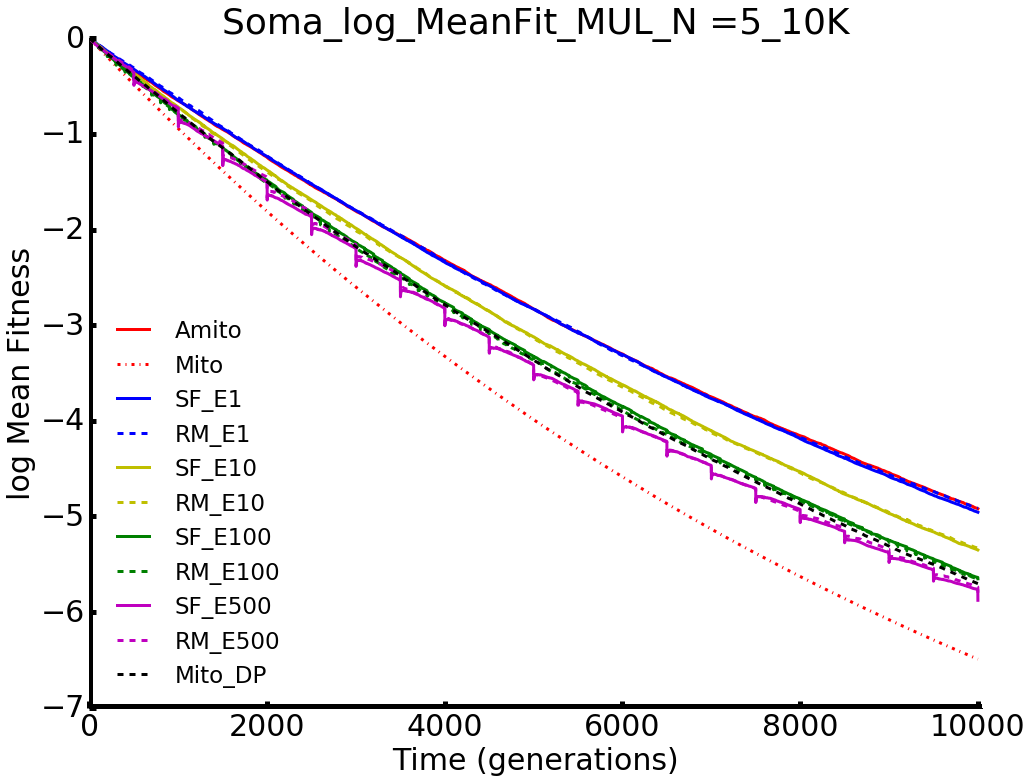

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import pylab

%matplotlib inline

plt.figure(figsize=(16,12))

t = generation_list
a = amito_log_mfit[0]
b = mito_log_mfit[0]
c = sf1_log_mfit[0]
d = rm1_log_mfit[0]
e = sf10_log_mfit[0]
f = rm10_log_mfit[0]
g = sf100_log_mfit[0]
h = rm100_log_mfit[0]
i = sf500_log_mfit[0]
j = rm500_log_mfit[0]
k = ds_mito_log_mfit[0]


plt.title('Soma_log_MeanFit_MUL_N =5_10K')
plt.xlabel('Time (generations)')
plt.ylabel('log Mean Fitness')
# plt.legend(['N =1', 'N =10', 'N =100', 'N =1000' ])
plt.rcParams.update({'font.size': 30})


# plt.show()
ax = plt.subplot(111)
ax.axhline(y=-7,linewidth=8, color ='black')       
ax.axvline(linewidth=8, color = 'black')        

plt.plot(t,a,'r', label = 'Amito', ls = 'solid',linewidth=3.0) # plotting t,a separately 
plt.plot(t,b,'r', label = 'Mito', ls= 'dashdot', linewidth=3.0) # plotting t,b separately 
plt.plot(t,c,'b', label = 'SF_E1', ls = 'solid', linewidth=3.0) # plotting t,c separately 
plt.plot(t,d,'b', label = 'RM_E1',ls = '--', linewidth=3.0)
plt.plot(t,e,'y', label = 'SF_E10', ls = 'solid', linewidth=3.0)
plt.plot(t,f,'y', label = 'RM_E10',ls= '--', linewidth=3.0)
plt.plot(t,g,'g', label = 'SF_E100',ls = 'solid', linewidth=3.0)
plt.plot(t,h,'g', label = 'RM_E100',ls = '--', linewidth=3.0)
plt.plot(t,i,'m', label = 'SF_E500', ls = 'solid', linewidth=3.0)
plt.plot(t,j,'m', label = 'RM_E500',ls= '--', linewidth=3.0)
plt.plot(t,k,'black', label = 'Mito_DP',ls= '--', linewidth=3.0)

plt.xlim(0, 10050)
# plt.axhline(y=-12)
# plt.axvline(x=0)



# Hide the right and top spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Only show ticks on the left and bottom spines
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')


ax.xaxis.set_tick_params(width=5, length =7)
ax.yaxis.set_tick_params(width=5, length =7)

# plt.legend(loc='upper right', frameon=False)
plt.legend(loc='lower left', frameon=False, prop={'size':23})

# plt.ylim(-0.1,0)
# plt.savefig('1', dpi=300, bbox_inches='tight')

plt.show()

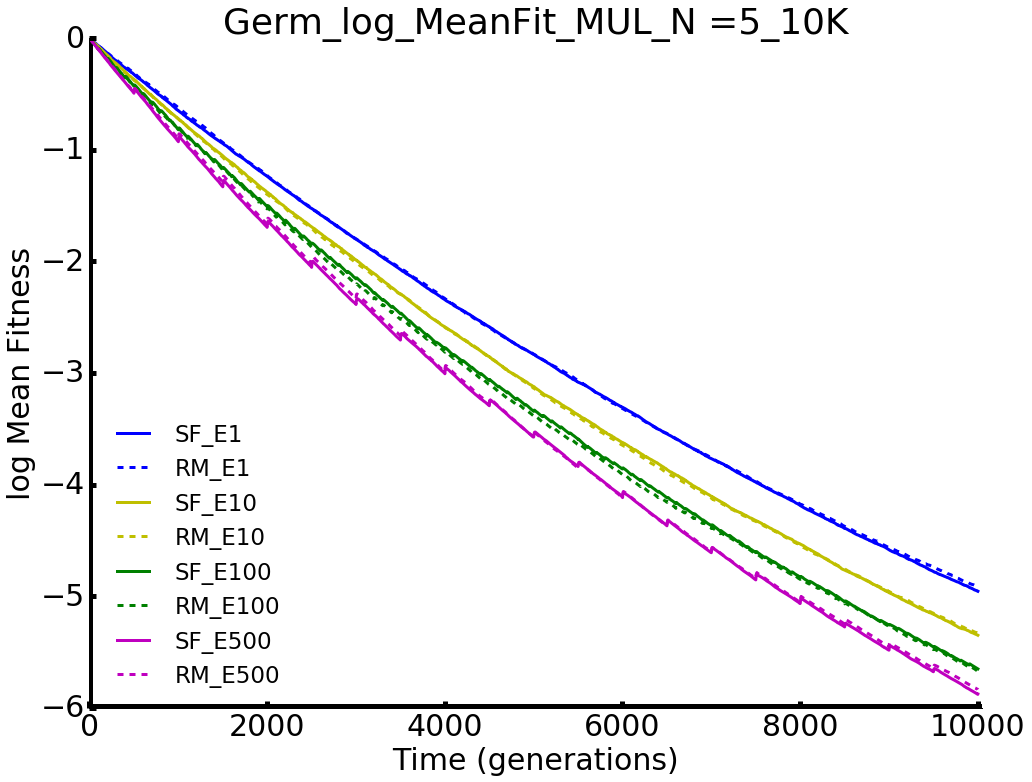

In [47]:
import matplotlib.pyplot as plt
import numpy as np
import pylab

%matplotlib inline

plt.figure(figsize=(16,12))

t = generation_list
a = g_amito_log_mfit[0]
b = g_mito_log_mfit[0]
c = g_sf1_log_mfit[0]
d = g_rm1_log_mfit[0]
e = g_sf10_log_mfit[0]
f = g_rm10_log_mfit[0]
g = g_sf100_log_mfit[0]
h = g_rm100_log_mfit[0]
i = g_sf500_log_mfit[0]
j = g_rm500_log_mfit[0]
k = ds_g_mito_log_mfit[0]


plt.title('Germ_log_MeanFit_MUL_N =5_10K')
plt.xlabel('Time (generations)')
plt.ylabel('log Mean Fitness')
# plt.legend(['N =1', 'N =10', 'N =100', 'N =1000' ])
plt.rcParams.update({'font.size': 30})


# plt.show()
ax = plt.subplot(111)
ax.axhline(y=-6,linewidth=8, color ='black')       
ax.axvline(linewidth=8, color = 'black')        

# plt.plot(t,a,'r', label = 'Amito', ls = 'solid',linewidth=3.0) # plotting t,a separately 
# plt.plot(t,b,'r', label = 'Mito', ls= 'dashdot', linewidth=3.0) # plotting t,b separately 
plt.plot(t,c,'b', label = 'SF_E1', ls = 'solid', linewidth=3.0) # plotting t,c separately 
plt.plot(t,d,'b', label = 'RM_E1',ls = '--', linewidth=3.0)
plt.plot(t,e,'y', label = 'SF_E10', ls = 'solid', linewidth=3.0)
plt.plot(t,f,'y', label = 'RM_E10',ls= '--', linewidth=3.0)
plt.plot(t,g,'g', label = 'SF_E100',ls = 'solid', linewidth=3.0)
plt.plot(t,h,'g', label = 'RM_E100',ls = '--', linewidth=3.0)
plt.plot(t,i,'m', label = 'SF_E500', ls = 'solid', linewidth=3.0)
plt.plot(t,j,'m', label = 'RM_E500',ls= '--', linewidth=3.0)
# plt.plot(t,k,'black', label = 'Mito_DP',ls= '--', linewidth=3.0)

plt.xlim(0, 10050)
# plt.axhline(y=-12)
# plt.axvline(x=0)



# Hide the right and top spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Only show ticks on the left and bottom spines
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')


ax.xaxis.set_tick_params(width=5, length =7)
ax.yaxis.set_tick_params(width=5, length =7)

# plt.legend(loc='upper right', frameon=False)
plt.legend(loc='lower left', frameon=False, prop={'size':23})

# plt.ylim(-0.1,0)
# plt.savefig('1', dpi=300, bbox_inches='tight')

plt.show()